In [1]:
import numpy as np
import pandas as pd
import re
import geopandas as gpd
from haversine import haversine, Unit
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import cKDTree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib, matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster

# 바나프레소 입지 적합도 분석

## 분석 목적
잘못된 입지 선택은 창업자에게 치명적인 손실을 초래할 수 있다.

바나프레소 예비 창업자에게 유동인구, 접근성, 입지점수 등을 분석하여

입지 선택 과정에서 발생하는 리스크를 줄이기 위함이다.

## 분석 목표

직방 크롤링 매물 데이터와 서울시 공공 데이터를 결합해  
바나프레소 신규 출점에 적합한 상가 매물을 추천한다.

### 데이터 수집
- 서울시 휴게음식점 인허가 정보
- 서울시 실시간 인구데이터
- 서울시 상권분석서비스(길단위인구-상권)
- 서울시 지식산업센터 현황
- 서울시 대형학원 정보
- 서울시 학교 기본정보
- 서울시 무도학원업 인허가 정보
- 서울시 체육도장업 인허가 정보
- 서울시 병원 인허가 정보
- 서울교통공사_역주소 및 전화번호
- 서울시 버스정류소 위치정보
- 서울시 대로변 횡단보도 위치정보
- 서울시 도로노선 정보

## 1. 바나프레소 매장 데이터 가져오기

서울시 음식점 인허가 데이터에서 바나프레소 매장만 추출하고, 

apv_date(영업 개시일) 기준으로 3년 이상 운영 중인 매장 = 성공(1)으로 둔다.



### 성공 기준을 3년으로 설정한 근거
소상공인진흥공단 연구(2020) 및 창업 생존율 관련 선행 연구에 따르면, 

외식업 창업 후 3년 이내 폐업률이 약 60%에 달하며,

3년 이상 생존한 매장은 안정적 수익 구조를 확보한 것으로 간주됩니다.  

-> 이에 따라 apv_date로부터 3년 이상 경과한 매장을 성공 매장으로 정의하였다.

In [2]:
cafe = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/mj/cafe.csv")
cafe.head()

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd
0,베레베레,커피숍,2002-09-19,서울 광진구 능동로13길 19,NaN,NaN,37.542885,127.070832,T,3120053.0,11215710
1,덕수궁전통차전문,커피숍,2003-01-16,서울 중구 서소문로 109,2.0,46.28,37.563062,126.973280,T,3120020.0,11140520
2,엘빠소,커피숍,2003-05-31,서울 종로구 성균관로 18,NaN,NaN,37.584406,126.997641,T,3110021.0,11110650
3,씨애틀즈베스트커피대사관점,커피숍,2003-10-31,서울 종로구 세종대로 188,1.0,NaN,37.573190,126.977831,A,NaN,11110615
4,본솔카페,커피숍,2004-01-17,서울 용산구 청파로47길 71,1.0,13.80,37.544840,126.966455,T,3110069.0,11170555


In [3]:
# 바나프레소만 추출
bana_df = cafe[cafe['nm'].str.contains(r"바나프레소|banapresso", case=False, na=False)].copy()
print('바나프레소 개수 : ')
print(len(bana_df))

# 날짜 변환
bana_df['apv_date'] = pd.to_datetime(bana_df['apv_date'], errors='coerce')

# 오늘 기준 3년 이상(=1)(3년 전 이하=0) 된 매장만
cutoff = pd.Timestamp.today().normalize() - pd.DateOffset(years=3)
bana_df["success"] = (bana_df["apv_date"] <= cutoff).astype(int)

# 확인
bana_df["success"].value_counts()

바나프레소 개수 : 
59


success
0    49
1    10
Name: count, dtype: int64

## 2. 수요 점수 변수 생성

### 2.1 유동인구 데이터 불러오기
 
최근 4개 분기(2024년 4분기 ~ 2025년 3분기) 평균값을 활용해 계절 편향을 줄인다.



In [4]:
print(bana_df["flpop_type"].unique())

['T' 'A']


In [5]:
flpop_t = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/mj/flpop_t.csv")
flpop_a = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/mj/flpop_a.csv")
print(flpop_t.columns)
print(flpop_a.columns)

Index(['stdr_yyqu_cd', 'trdar_se_cd_nm', 'trdar_cd', 'trdar_cd_nm',
       'tot_flpop_co', 'ml_flpop_co', 'fml_flpop_co', 'agrde_10_flpop_co',
       'agrde_20_flpop_co', 'agrde_30_flpop_co', 'agrde_40_flpop_co',
       'agrde_50_flpop_co', 'agrde_60_above_flpop_co', 'tmzon_00_06_flpop_co',
       'tmzon_06_11_flpop_co', 'tmzon_11_14_flpop_co', 'tmzon_14_17_flpop_co',
       'tmzon_17_21_flpop_co', 'tmzon_21_24_flpop_co', 'mon_flpop_co',
       'tues_flpop_co', 'wed_flpop_co', 'thur_flpop_co', 'fri_flpop_co',
       'sat_flpop_co', 'sun_flpop_co'],
      dtype='object')
Index(['stdr_yyqu_cd', 'adstrd_cd', 'adstrd_cd_nm', 'tot_flpop_co',
       'ml_flpop_co', 'fml_flpop_co', 'agrde_10_flpop_co', 'agrde_20_flpop_co',
       'agrde_30_flpop_co', 'agrde_40_flpop_co', 'agrde_50_flpop_co',
       'agrde_60_above_flpop_co', 'tmzon_00_06_flpop_co',
       'tmzon_06_11_flpop_co', 'tmzon_11_14_flpop_co', 'tmzon_14_17_flpop_co',
       'tmzon_17_21_flpop_co', 'tmzon_21_24_flpop_co', 'mon_flpop_co

In [6]:

# 최근 4개 분기 추출
recent_quarters = sorted(flpop_t["stdr_yyqu_cd"].unique())[-4:]

# 필터링
flpop_t = flpop_t[flpop_t["stdr_yyqu_cd"].isin(recent_quarters)]
flpop_a = flpop_a[flpop_a["stdr_yyqu_cd"].isin(recent_quarters)]

In [7]:
print(flpop_t[["stdr_yyqu_cd","trdar_cd"]].duplicated().sum())
print(flpop_a[["stdr_yyqu_cd","adstrd_cd"]].duplicated().sum())

0
0


### 2.2 시간대별 유동인구

카페 매출과 연관성이 높은 시간대를 선별


-  점심_유동 인구: tmzon_11_14_flpop_co
-  저녁_유동 인구: tmzon_17_21_flpop_co
-  평균시간_유동 인구: tmzon_00_06_flpop_co, tmzon_06_11_flpop_co, tmzon_14_17_flpop_co, tmzon_21_24_flpop_co

In [8]:
# 분기 평균 집계
agg_cols = ["tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co",
            "tmzon_00_06_flpop_co", "tmzon_06_11_flpop_co",
            "tmzon_14_17_flpop_co", "tmzon_21_24_flpop_co"]

flpop_t_agg = flpop_t.groupby("trdar_cd")[agg_cols].mean().reset_index()
flpop_a_agg = flpop_a.groupby("adstrd_cd")[agg_cols].mean().reset_index()

# etc 평균 계산
etc_cols = ["tmzon_00_06_flpop_co", "tmzon_06_11_flpop_co", "tmzon_14_17_flpop_co", "tmzon_21_24_flpop_co"]
flpop_t_agg["flpop_etc"] = flpop_t_agg[etc_cols].mean(axis=1)
flpop_a_agg["flpop_etc"] = flpop_a_agg[etc_cols].mean(axis=1)

In [9]:
flpop_a_agg

,adstrd_cd,tmzon_11_14_flpop_co,tmzon_17_21_flpop_co,tmzon_00_06_flpop_co,tmzon_06_11_flpop_co,tmzon_14_17_flpop_co,tmzon_21_24_flpop_co,flpop_etc
0,11110515,500612.50,578186.75,764008.75,695880.25,496522.75,396395.75,5.882019e+05
1,11110530,785096.00,800972.75,462503.75,833639.75,795807.75,329475.00,6.053566e+05
2,11110540,189512.25,162304.25,158158.75,197656.50,187852.75,80772.75,1.561102e+05
3,11110550,113146.00,138369.00,233406.50,193447.25,109598.75,114718.50,1.627928e+05
4,11110560,95763.00,138732.75,263526.50,190671.50,94246.75,123374.00,1.679547e+05
...,...,...,...,...,...,...,...,...
420,11740650,920444.50,1377540.25,2302846.00,1689404.25,935937.50,1107762.25,1.508988e+06
421,11740660,762420.50,1072372.75,1852932.25,1368657.50,746946.00,885058.75,1.213399e+06
422,11740685,2099678.75,2972146.50,4900869.50,3691237.75,2090460.00,2401415.00,3.270996e+06
423,11740690,2754.75,3662.25,6182.75,4974.50,2686.75,2983.00,4.206750e+03


### 2.3 바나프레소 매장 데이터(bana_df), 유동인구 데이터 merge

In [10]:
# flpop_type T 매핑
tr_mask = bana_df["flpop_type"] == "T"
tr_merged = bana_df[tr_mask].merge(
    flpop_t_agg[["trdar_cd", "tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co", "flpop_etc"]],
    on="trdar_cd", how="left"
)

# flpop_type A 매핑
ad_mask = bana_df["flpop_type"] == "A"
ad_merged = bana_df[ad_mask].merge(
    flpop_a_agg[["adstrd_cd", "tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co", "flpop_etc"]],
    on="adstrd_cd", how="left"
)

# 합치기 & 컬럼명 정리
bana_df = pd.concat([tr_merged, ad_merged]).sort_index().rename(columns={
    "tmzon_11_14_flpop_co": "flpop_lunch",
    "tmzon_17_21_flpop_co": "flpop_dinner"
})

print(bana_df.shape)
bana_df.head()

(59, 15)


,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd,success,flpop_lunch,flpop_dinner,flpop_etc
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,11680650,1,985131.50,882135.00,752222.8125
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,11350621,0,418872.50,654206.75,676400.0625
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,11650531,1,589152.00,788268.00,560948.1250
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,11710647,0,353384.75,554050.25,582902.9375
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,11680590,1,951358.25,983513.00,833761.1250


In [11]:
len(bana_df)

59

### 2.4 주변 상권 데이터 불러오기

- 학원 
- 체육도장
- 병원
- 무도
- 학교
- 지식산업센터

In [12]:
academy = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/sa/seoul_data/academy_df.csv")
gym = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/sa/seoul_data/gym_df.csv")
hospital = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/sa/seoul_data/hospital_df.csv")
physical = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/sa/seoul_data/physical_df.csv")
school = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/sa/seoul_data/school.csv")
center = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/mj/industry_center.csv")
print('학원:')
print(academy.columns)
print('체육도장:')
print(gym.columns)
print('병원:')
print(hospital.columns)
print('무도:')
print(physical.columns)
print('학교:')
print(school.columns)
print('지산:')
print(center.columns)

학원:
Index(['idx', 'nm', 'addr', 'lat', 'lng'], dtype='object')
체육도장:
Index(['idx', 'dtlstatenm', 'addr', 'nm', 'type', 'lat', 'lng'], dtype='object')
병원:
Index(['idx', 'dtlstatenm', 'nm', 'type', 'addr', 'lat', 'lng'], dtype='object')
무도:
Index(['idx', 'dtlstatenm', 'addr', 'type', 'nm', 'lat', 'lng'], dtype='object')
학교:
Index(['idx', 'nm', 'addr', 'type', 'lat', 'lng'], dtype='object')
지산:
Index(['nm', 'type', 'addr', 'lat', 'lng'], dtype='object')


In [13]:
# academy 에 type 칼럼이 없어서 추가
academy['type'] = '학원'
academy.head()

,idx,nm,addr,lat,lng,type
0,1,클릭전원미술학원,서울특별시 마포구 와우산로 138 (창전동),37.553572,126.928993,학원
1,2,고려직업전문학교,서울특별시 동작구 노량진로 186 (노량진동),37.512575,126.946031,학원
2,3,노량진행정고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198,학원
3,4,박문각임용고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198,학원
4,5,노량진메가스터디입시어학원,서울특별시 동작구 장승배기로 171 (노량진동),37.513017,126.939945,학원


### 2.5 시설 데이터 통합

- 학원
- 무도
- 체육도장

업종 특성이 유사한 시설을 하나의 type 으로 통합


In [14]:
gym.head(5)

,idx,dtlstatenm,addr,nm,type,lat,lng
0,1,영업중,"서울특별시 강동구 양재대로 1393, 지층 (성내동)",미르메,학원,37.530484,127.136840
1,2,영업중,"서울특별시 강동구 진황도로 190, 6층 (둔촌동)",한국체대우리태권도,학원,37.529261,127.142992
2,3,영업중,"서울특별시 강동구 상암로 425, 2층 (상일동)",상일유도스쿨,학원,37.545828,127.169810
3,4,영업중,"서울특별시 강동구 구천면로 250, 신성빌딩 5층 (천호동)",캡틴복싱클럽,학원,37.542516,127.131457
4,5,영업중,"서울특별시 강동구 상일로 31-1, 2층 (상일동)",한국위너복싱 상일동점,학원,37.549938,127.172743


In [15]:
dfs = [academy, gym, hospital, physical, school, center]

need_cols = ["type", "nm", "addr", "lat", "lng"]

# 각 df에서 필요한 컬럼만 추출(없는 컬럼은 NaN으로 생성)
picked = [d.reindex(columns=need_cols) for d in dfs]

# 세로로 합치기
buildings_df = pd.concat(picked, ignore_index=True)

buildings_df.head()

,type,nm,addr,lat,lng
0,학원,클릭전원미술학원,서울특별시 마포구 와우산로 138 (창전동),37.553572,126.928993
1,학원,고려직업전문학교,서울특별시 동작구 노량진로 186 (노량진동),37.512575,126.946031
2,학원,노량진행정고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198
3,학원,박문각임용고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198
4,학원,노량진메가스터디입시어학원,서울특별시 동작구 장승배기로 171 (노량진동),37.513017,126.939945


In [16]:
buildings_df['type'].unique()

array(['학원', '병원', '학교', '지식산업센터'], dtype=object)

### 2.6 Feature Engineering

바나프레소 매장 위치를 기준으로 반경 300m 안에 있는 시설 수를 계산해 feature 만들기

| 피처 | 대상 데이터 | 의미 |
|------|------------|------|
| cnt_academy | 학원·체육도장·무도 | 10~40대 유동인구 집중 |
| cnt_hospital | 병원 | 대기 중 카페 방문 유도 |
| cnt_school | 학교 | 학생·학부모 수요 |
| cnt_company | 지식산업센터 | 직장인 커피 수요 |

- 매장 수(59건)가 적어 행 단위 haversine(위도와 경도를 이용해 지구 곡면 기준 실제 거리를 계산 공식)사용.  


In [17]:

type_map = {
    "학원": "cnt_academy",
    "병원": "cnt_hospital",
    "학교": "cnt_school",
    "지식산업센터": "cnt_company"
}
# 매장 위치, 반경 300m, 주변 시설 개수 계산
def count_buildings_nearby(cafe_lat, cafe_lon, buildings_df, radius=300):
    mask = buildings_df.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ) <= radius, axis=1
    )
    nearby = buildings_df[mask]
    counts = nearby.groupby("type").size()
    
    # 없는 type도 0으로 채우기
    counts = counts.reindex(type_map.keys(), fill_value=0)
    
    # 영소문자로 변경
    counts.index = [type_map[t] for t in counts.index]
    return counts


result = bana_df.apply(
    lambda row: count_buildings_nearby(row["lat"], row["lng"], buildings_df),
    axis=1
).fillna(0).astype(int)

bana_df = pd.concat([bana_df, result], axis=1)
bana_df.head()

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd,success,flpop_lunch,flpop_dinner,flpop_etc,cnt_academy,cnt_hospital,cnt_school,cnt_company
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,11680650,1,985131.50,882135.00,752222.8125,0,1,0,0
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,11350621,0,418872.50,654206.75,676400.0625,0,0,0,0
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,11650531,1,589152.00,788268.00,560948.1250,0,1,0,0
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,11710647,0,353384.75,554050.25,582902.9375,0,0,0,0
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,11680590,1,951358.25,983513.00,833761.1250,1,2,0,0


## 3. 접근성 점수 변수 생성

### 3.1 접근성 데이터 불러오기

카페 접근 편의성에 직접적으로 영향을 미치는 4가지 데이터 사용

| 데이터 | 활용 목적 |
|--------|----------|
| 버스정류장 | 대중교통 접근성 (최근접 거리) |
| 지하철역 | 역세권 여부 판단 (최근접 거리) |
| 횡단보도 | 보행자 유동 흐름 — 많을수록 보행량 多 |
| 도로 | 대로변 여부 — 가시성·접근성 직결 |

In [18]:
bus_stop = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/dh/bus_stop.csv")
station = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/dh/station.csv")
crosswalk = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/dh/crosswalk.csv")
road = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/dh/road.csv")

print('버스정류장 :')
print(bus_stop.columns)
print('지하철 :')
print(station.columns)
print('횡단보도 :')
print(crosswalk.columns)
print('도로 :')
print(road.columns)

버스정류장 :
Index(['bus_stop_id', 'bus_stop_nm', 'lng', 'lat', 'type'], dtype='object')
지하철 :
Index(['addr', 'type', 'lat', 'lng'], dtype='object')
횡단보도 :
Index(['lng', 'lat', 'sigungu', 'emd', 'type'], dtype='object')
도로 :
Index(['road_address', 'lng', 'lat', 'type'], dtype='object')


### 3.2 Feature Engineering

| 피처 | 계산 방법 |
|------|-----------|
| dist_station | 각 매장→모든 지하철역 haversine 거리 중 최솟값 | 
| dist_bus_stop | 각 매장→모든 버스정류장 haversine 거리 중 최솟값 |
| cnt_crosswalk | 반경 300m 내 횡단보도 개수 |
| is_road | 반경 50m 내 대로 데이터 존재 → 1, 없으면 0 | 

- 매장 수(59건)가 적어 행 단위 haversine(위도와 경도를 이용해 지구 곡면 기준 실제 거리를 계산 공식)사용.  

In [19]:
# 최소 거리
def min_distance(cafe_lat, cafe_lon, df):
    distances = df.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ), axis=1
    )
    return distances.min()

# 300m 안 횡단보도 개수
def count_within(cafe_lat, cafe_lon, df, radius=300):
    mask = df.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ) <= radius, axis=1
    )
    return mask.sum()

# 300m 안 대로변 여부
def is_roadside(cafe_lat, cafe_lon, df, radius=300):
    mask = df.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ) <= radius, axis=1
    )
    return int(mask.any())  # 1개라도 있으면 1, 없으면 0

# bana_old_df에 적용
bana_df["dist_station"]    = bana_df.apply(lambda row: min_distance(row["lat"], row["lng"], station), axis=1)
bana_df["dist_bus_stop"]   = bana_df.apply(lambda row: min_distance(row["lat"], row["lng"], bus_stop), axis=1)
bana_df["cnt_crosswalk"] = bana_df.apply(lambda row: count_within(row["lat"], row["lng"], crosswalk), axis=1)
bana_df["is_road"]     = bana_df.apply(lambda row: is_roadside(row["lat"], row["lng"], road), axis=1)
bana_df.head(5)

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,...,flpop_dinner,flpop_etc,cnt_academy,cnt_hospital,cnt_school,cnt_company,dist_station,dist_bus_stop,cnt_crosswalk,is_road
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,...,882135.00,752222.8125,0,1,0,0,223.598018,24.766102,8,1
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,...,654206.75,676400.0625,0,0,0,0,750.922345,116.274918,18,1
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,...,788268.00,560948.1250,0,1,0,0,765.979395,57.031538,18,1
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,...,554050.25,582902.9375,0,0,0,0,1379.887436,72.955206,23,1
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,...,983513.00,833761.1250,1,2,0,0,258.610257,139.653177,16,1


## 4. 경쟁사 비교 점수 변수 생성

- 바나프레소 수
- 대형 카페 존재 여부
- 저가 프랜차이즈 수
- 기타 카페 수

In [20]:
cafe_nm = cafe['nm']
cafe_nm = cafe_nm.to_list()
cafe_nm

['베레베레',
 '덕수궁전통차전문',
 '엘빠소',
 '씨애틀즈베스트커피대사관점',
 '본솔카페',
 '링고요고',
 '토넷트커피숍',
 '썬휴게실',
 '네스카페',
 '루비콘플러스',
 '구스토',
 '아름다운고궁',
 '피카디리망고 일리',
 '소그노스에스프레소',
 '노모토커피',
 '주)키커피코리아',
 '강남커피숍',
 '캔모아',
 '북카페내서재',
 '플로리안',
 'BABIANA(바비아나)',
 '숭실대생협 아름다운세상',
 '보보스',
 '에스프레소인뉴욕',
 '할리스커피(Hollys Coffee)',
 '제일상회',
 '국립고궁박물관 뮤지엄숍',
 '모드뜨레',
 '카페돌로미티',
 '카페하임',
 '미래월드',
 '커피501(coffee501)',
 '메리메이트(MerryMate)',
 '귀천',
 '탐앤탐스노원점',
 '커피투어(Coffee Tour)',
 '쿠벅양평점',
 '세리커피(Coffee)',
 '테라 스위트(Terra sweet)본점',
 '물커피(Mool Coffee)',
 '세븐일레븐(서울시립대점)',
 '#11(Sharp eleven)',
 '커피보노',
 'ATM(에이티엠)',
 '미르엠(MIRM)',
 '토프레소 태평로점',
 'POLE243',
 'Meister haus',
 '빈스빈스',
 '이디야커피',
 '소풍',
 '다동커피집',
 '파나마',
 '동네커피',
 '영화에 빠진 커피',
 '두루',
 '니들 북',
 '헤이리커피공장103이촌점',
 '퓨얼리데카던트',
 '이디야올림픽공원점',
 '카페베네 종로5가점',
 '이디야 서대문점',
 '남산커피집',
 '보티',
 '커피데이',
 '아산엠 매점',
 '까사안띠구아',
 '커피홀릭',
 '카페깔리아리',
 '파반커피',
 '카페나루',
 '카페라비',
 '투미',
 '호텔디아망',
 '빈스커피',
 '투썸플레이스',
 '야노아',
 'An.s coffee',
 '슐레스',
 '알엔비스커피(RNBS COFFEE)',
 '아임빈',
 '바오밥나무 여성미래센

### 4.1 Feature Engineering

- 카페 이름을 정규화
- 브랜드 키워드 탐색
- 카페 등급 분류

In [21]:
# 이름 정규화
def norm(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"[\s\.\,\-\(\)\[\]\/_]", "", s)  # 공백/기호 제거
    return s

# 브랜드 키워드
LOW_PATTERNS = [
    "메가엠지씨", "메가mgc", "메가커피",
    "빽다방",
    "컴포즈", "compose",
    "더벤티", "theventi",
    "매머드", "mammoth",
    "텐퍼센트", "tenpercent",
    "커피베이",
    "우지커피", "oozy",
    "백억커피",
    "벤티프레소", "ventipresso",
]

HIGH_PATTERNS = [
    "스타벅스", "starbucks",
    "투썸", "twosome",
    "폴바셋", "paulbassett",
    "커피빈", "coffeebean",
    "할리스", "hollys",
    "아티제", "artisee",
    "테라로사", "terarosa",
    "오설록", "osulloc",
]

BANA_PATTERNS = ["바나프레소", "banapresso"]

def contains_any(text, patterns):
    return any(p in text for p in patterns)


# 카페 등급 분류
def cafe_tier(name):
    x = norm(name)
    if contains_any(x, BANA_PATTERNS):
        return "banapresso"
    if contains_any(x, HIGH_PATTERNS):
        return "high"
    if contains_any(x, LOW_PATTERNS):
        return "low"
    return "etc"


cafe["detail"] = cafe["nm"].apply(cafe_tier)

print('카페별 갯수 :')
print(cafe["detail"].value_counts())
cafe.head()

카페별 갯수 :
detail
etc           11194
low            2209
high           1071
banapresso       59
Name: count, dtype: int64


,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd,detail
0,베레베레,커피숍,2002-09-19,서울 광진구 능동로13길 19,NaN,NaN,37.542885,127.070832,T,3120053.0,11215710,etc
1,덕수궁전통차전문,커피숍,2003-01-16,서울 중구 서소문로 109,2.0,46.28,37.563062,126.973280,T,3120020.0,11140520,etc
2,엘빠소,커피숍,2003-05-31,서울 종로구 성균관로 18,NaN,NaN,37.584406,126.997641,T,3110021.0,11110650,etc
3,씨애틀즈베스트커피대사관점,커피숍,2003-10-31,서울 종로구 세종대로 188,1.0,NaN,37.573190,126.977831,A,NaN,11110615,etc
4,본솔카페,커피숍,2004-01-17,서울 용산구 청파로47길 71,1.0,13.80,37.544840,126.966455,T,3110069.0,11170555,etc


- 매장 위치
- 반경 300m 카페
- 브랜드 등급별 경쟁 카페 수 계산

In [22]:

detail_map = {
    "banapresso": "cnt_banapresso",
    "high": "cnt_high_cafe",
    "low": "cnt_low_cafe",
    "etc": "cnt_etc_cafe"
}

# 경쟁 카페 계산 함수
def count_cafes_nearby(cafe_lat, cafe_lon, cafe_idx, cafes_df, radius=300):
    
    other_cafes = cafes_df.drop(index=cafe_idx)
    # 거리 계산
    mask = other_cafes.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ) <= radius, axis=1
    )
    # 주변 카페 추출
    nearby = other_cafes[mask]
    counts = nearby.groupby("detail").size()
    
    # 없는 type도 0으로 채우기
    counts = counts.reindex(detail_map.keys(), fill_value=0)
    counts.index = [detail_map[d] for d in counts.index]
    return counts


result = bana_df.apply(
    lambda row: count_cafes_nearby(row["lat"], row["lng"], row.name, cafe),
    axis=1
).fillna(0).astype(int)

bana_df = pd.concat([bana_df, result], axis=1)
bana_df.head(5)

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,...,cnt_school,cnt_company,dist_station,dist_bus_stop,cnt_crosswalk,is_road,cnt_banapresso,cnt_high_cafe,cnt_low_cafe,cnt_etc_cafe
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,...,0,0,223.598018,24.766102,8,1,1,6,6,27
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,...,0,0,750.922345,116.274918,18,1,1,0,1,2
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,...,0,0,765.979395,57.031538,18,1,1,6,8,36
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,...,0,0,1379.887436,72.955206,23,1,1,0,1,5
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,...,0,0,258.610257,139.653177,16,1,1,1,10,25


### 4.2 인덱스 재정렬

In [23]:
bana_df = bana_df.reset_index(drop=True)
bana_df.tail(5)

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,...,cnt_school,cnt_company,dist_station,dist_bus_stop,cnt_crosswalk,is_road,cnt_banapresso,cnt_high_cafe,cnt_low_cafe,cnt_etc_cafe
54,바나프레소 용산센트럴파크점,커피숍,2026-01-06,서울 용산구 서빙고로 17,1.0,40.53,37.526906,126.966566,T,3120041.0,...,0,0,334.613865,53.466815,36,1,1,4,9,30
55,바나프레소 강남역 신분당선점,커피숍,2026-01-08,서울 강남구 강남대로 302-2,-1.0,32.38,37.490350,127.031507,T,3120192.0,...,0,0,762.047469,93.900274,17,1,1,6,5,31
56,바나프레소 동부이촌점,커피숍,2026-01-12,서울 용산구 이촌로 248,1.0,45.75,37.519387,126.975026,T,3110078.0,...,0,0,368.022665,68.813440,3,1,1,1,1,6
57,바나프레소 동소문점,커피숍,2023-07-21,서울 성북구 아리랑로 15,1.0,60.00,37.594241,127.015930,T,3120072.0,...,1,0,176.130876,58.610849,18,1,1,4,5,26
58,바나프레소 압구정SLP점,커피숍,2026-02-24,서울 강남구 논현로163길 23,1.0,131.66,37.524037,127.026247,T,3120188.0,...,1,0,331.127404,173.242280,6,1,2,4,3,33


In [24]:
bana_df.to_csv("bana_old.csv", index=False, encoding="utf-8-sig")
print('결과 저장 완료: bana_old.csv')

결과 저장 완료: bana_old.csv


## 5. 도메인 지식 기반 입지 점수 산출

수요 점수 + 접근성 점수 + 경쟁사 점수를 도메인 지식 기반 가중치로 합산해 location_score 산출.


- 유동인구(40%) > 접근성(25%) > 주변시설(25%) > 경쟁강도(10%)

### 5.1 데이터 결측치 확인 (없음)

In [25]:
print(bana_df[["flpop_lunch", "flpop_dinner", "flpop_etc"]].isnull().sum())

flpop_lunch     0
flpop_dinner    0
flpop_etc       0
dtype: int64


### 5.2 실패 매장 (창업 3년 미만) 개점일 확인

- count  :실패 매장 수 
- mean   :평균 개점일 
- min    :가장 오래된 매장
- 25%    :하위 25%
- 50%    :중앙값
- 75%    :상위 25%
- max    :가장 최근 매장

In [26]:
print("실패 매장 : ")
print(bana_df[bana_df["success"]==0]["apv_date"].describe())

실패 매장 : 
count                     49
mean     2024-11-19 00:00:00
min      2023-03-24 00:00:00
25%      2024-02-21 00:00:00
50%      2025-01-06 00:00:00
75%      2025-09-11 00:00:00
max      2026-02-24 00:00:00
Name: apv_date, dtype: object


### 5.3 성공 매장과 실패 매장의 피처 평균 비교

두 그룹의 평균값 차이를 통해 어떤 피처가 성공과 연관되는지 확인

In [27]:

feature_cols = [
    "flpop_lunch", "flpop_dinner", "flpop_etc",
    "dist_station", "dist_bus_stop",
    "cnt_crosswalk", "is_road",
    "cnt_academy", "cnt_hospital", "cnt_school", "cnt_company",
    "cnt_banapresso", "cnt_high_cafe", "cnt_low_cafe", "cnt_etc_cafe"
]

# 최적 입지
ideal_profile = bana_df[bana_df["success"] == 1][feature_cols].mean()
print(ideal_profile)

flpop_lunch       474698.150000
flpop_dinner      498050.025000
flpop_etc         395850.031250
dist_station         286.072193
dist_bus_stop         71.122346
cnt_crosswalk         20.900000
is_road                1.000000
cnt_academy            0.100000
cnt_hospital           0.800000
cnt_school             0.000000
cnt_company            0.500000
cnt_banapresso         1.000000
cnt_high_cafe          3.800000
cnt_low_cafe           4.900000
cnt_etc_cafe          28.200000
dtype: float64


### 5.4 성공 매장의 평균 입지 특성 해석

| 특성 | 해석 |
|------|------|
| 유동인구 높음 (점심 47만·저녁 50만) | 카페는 지나가다 들어오는 업종 → 사람이 많아야 매출 |
| 지하철 평균 286m | 역세권 필수, 도보 5분 이내 |
| 버스 71m | 가장 가까운 정류장까지 거의 1분 거리 |
| is_road = 1.0 | 성공 매장 **100%** 대로변 위치 |
| cnt_etc_cafe = 28개 | 경쟁이 많은 곳 = 오히려 상권 활성화된 곳 |


가중치 배분: 유동인구 40% + 접근성 25% + 주변시설 25% + 경쟁강도 10%

### 5.5 기존 바나프레소 매장으로 입지 점수 검증

Logistic Regression 학습 전에, 도메인 가중치로 산출한 location_score가 실제로 성공 매장을 상위권에 배치하는지 확인.


In [28]:
# 입지 특성 컬럼 정의
feature_cols = [
    "flpop_lunch", "flpop_dinner", "flpop_etc",
    "dist_station", "dist_bus_stop",
    "cnt_crosswalk", "is_road",
    "cnt_academy", "cnt_hospital", "cnt_school", "cnt_company",
    "cnt_banapresso", "cnt_high_cafe", "cnt_low_cafe", "cnt_etc_cafe"
]

# 방향 정의
higher_better = [
    "flpop_lunch", "flpop_dinner", "flpop_etc",
    "cnt_crosswalk", "is_road",
    "cnt_academy", "cnt_hospital", "cnt_school", "cnt_company",
    "cnt_high_cafe", "cnt_low_cafe", "cnt_etc_cafe"
]
lower_better = ["dist_station", "dist_bus_stop", "cnt_banapresso"]

# 가중치
weights = {
    "flpop_lunch": 0.15, "flpop_dinner": 0.15, "flpop_etc": 0.10,
    "dist_station": 0.10, "dist_bus_stop": 0.08,
    "cnt_crosswalk": 0.07, "is_road": 0.05,
    "cnt_academy": 0.05, "cnt_hospital": 0.05,
    "cnt_school": 0.05, "cnt_company": 0.05,
    "cnt_banapresso": 0.02, "cnt_high_cafe": 0.03,
    "cnt_low_cafe": 0.02, "cnt_etc_cafe": 0.03,
}

# lower_better 반전 후 정규화
score_df = bana_df[feature_cols].copy()
for col in lower_better:
    score_df[col] = -score_df[col]

scaler = MinMaxScaler()
score_scaled = pd.DataFrame(
    scaler.fit_transform(score_df),
    columns=feature_cols,
    index=bana_df.index
)

# 가중치 적용 → 최종 점수
bana_df["location_score"] = score_scaled.apply(
    lambda row: sum(row[col] * weights[col] for col in weights), axis=1
)

# success 그룹별 평균 점수
print(bana_df.groupby("success")["location_score"].mean())

# 점수 순위
bana_df[["nm", "location_score", "success"]].sort_values("location_score", ascending=False).head(10)

success
0    0.343460
1    0.404263
Name: location_score, dtype: float64


,nm,location_score,success
26,바나프레소 강남역아라타워점,0.828385,0
45,바나프레소 신림역점,0.547578,0
4,바나프레소 선릉공원점,0.532973,1
0,바나프레소 테헤란로점,0.532725,1
50,바나프레소 그랑서울점,0.516871,0
43,바나프레소 서울대입구역점,0.492769,0
49,바나프레소 을지로3가역점,0.453274,0
57,바나프레소 동소문점,0.445601,0
29,바나프레소 서울성균관대점,0.440952,0
2,바나프레소 신논현역점,0.437987,1


## 6. MinMaxScaling


### 6.1 직방 크롤링 매물 데이터 불러오기

직방 상가 매물 페이지를 크롤링한 데이터 불러오기

In [29]:
listing_df = pd.read_csv("/Users/danha/Desktop/IT/project/team_project_brew_map/Brewmap/data/mj/listing.csv")
listing_df.head()

,listing_id,addr,lat,lng,business_type,transaction_type,sale_price,key_money,deposit,monthly_rent,maintenance_fee,size_m2,floor,flpop_type,trdar_cd,adstrd_cd
0,575115,서울특별시 강남구 논현동,37.519306,127.029262,사무실,월세,0,0,30000000,2000000,0,82.60,4층,T,3120190,11680531
1,703777,서울특별시 서초구 잠원동,37.511775,127.020540,카페/커피,월세,0,40000000,50000000,3000000,0,33.06,1층,T,3120185,11650540
2,701846,서울특별시 강남구 논현동,37.512658,127.021577,사무실,월세,0,0,35000000,3000000,0,49.59,2층,T,3120185,11680521
3,455221,서울특별시 강남구 논현동,37.509032,127.023453,한식/고기집,월세,0,220000000,80000000,5500000,1200000,264.50,2층,T,3130303,11680521
4,394623,서울특별시 강남구 논현동,37.515856,127.030844,가구/가전,월세,0,200000000,50000000,3100000,600000,165.00,1층,T,3120191,11680531


### 6.2 매물 기본 전처리

원단위 금액을 만원 단위로, ㎡를 평으로 변환합니다.


- 원 → 만원 -> ÷ 10,000 
- ㎡ → 평 -> ÷ 3.3058 

In [30]:
listing_df['deposit_만원']      = listing_df['deposit']      / 10_000
listing_df['monthly_rent_만원'] = listing_df['monthly_rent'] / 10_000
listing_df['size_평']           = (listing_df['size_m2'] / 3.3058).round(1)

print(f'전체 매물: {len(listing_df):,}건')
listing_df[['deposit_만원','monthly_rent_만원','size_평']].describe().round(1)

전체 매물: 1,319건


,deposit_만원,monthly_rent_만원,size_평
count,1319.0,1319.0,1319.0
mean,6140.2,487.0,39.3
std,8845.2,727.8,43.1
min,0.0,0.0,1.0
25%,2000.0,200.0,17.0
50%,4000.0,300.0,30.0
75%,6500.0,500.0,45.3
max,108000.0,9200.0,548.5


### 6.3 유동인구 매핑

- flpop_type == 'T' → trdar_cd + flpop_t_agg merge
- flpop_type == 'A' → adstrd_cd + flpop_a_agg merge

In [31]:
tr_mask_l = listing_df['flpop_type'] == 'T'
a_mask_l  = listing_df['flpop_type'] == 'A'

tr_merged_l = listing_df[tr_mask_l].merge(
    flpop_t_agg[['trdar_cd','tmzon_11_14_flpop_co','tmzon_17_21_flpop_co','flpop_etc']],
    on='trdar_cd', how='left'
)
a_merged_l = listing_df[a_mask_l].merge(
    flpop_a_agg[['adstrd_cd','tmzon_11_14_flpop_co','tmzon_17_21_flpop_co','flpop_etc']],
    on='adstrd_cd', how='left'
)

listing_df = pd.concat([tr_merged_l, a_merged_l]).sort_index()
listing_df.rename(columns={
    'tmzon_11_14_flpop_co': 'flpop_lunch',
    'tmzon_17_21_flpop_co': 'flpop_dinner'
}, inplace=True)

for col in ['flpop_lunch','flpop_dinner','flpop_etc']:
    listing_df[col] = listing_df[col].fillna(0)

print(f'유동인구 매핑 완료: {len(listing_df):,}건')

유동인구 매핑 완료: 1,319건


### 6.4 주변시설 · 접근성 · 경쟁카페 피처

- 입지 환경 정량화
- cKDTree(좌표 데이터에서 가까운 점을 빠르게 찾기 위한공간 인덱스 알고리즘) 사용

In [32]:
#위도경도 -> 평명 좌표 반환
SCALE_LAT, SCALE_LNG = 111_000, 88_800

#주변 시설 개수 계산
def count_nearby(lats, lngs, ref_df, radius_m):
    ref = np.column_stack([ref_df['lat'].values * SCALE_LAT,
                           ref_df['lng'].values * SCALE_LNG])
    tgt = np.column_stack([lats * SCALE_LAT, lngs * SCALE_LNG])
    return cKDTree(ref).query_ball_point(tgt, r=radius_m, return_length=True)

# 최소 거리 계산
def min_dist(lats, lngs, ref_df):
    ref  = np.column_stack([ref_df['lat'].values * SCALE_LAT,
                            ref_df['lng'].values * SCALE_LNG])
    tgt  = np.column_stack([lats * SCALE_LAT, lngs * SCALE_LNG])
    dist, _ = cKDTree(ref).query(tgt, k=1)
    return dist

# 매물 좌표 추출
la, ln = listing_df['lat'].values, listing_df['lng'].values

#주변 시설 개수 계산
for btype, col in [('학원','cnt_academy'), ('병원','cnt_hospital'),
                    ('학교','cnt_school'),  ('지식산업센터','cnt_company')]:
    sub = buildings_df[buildings_df['type']==btype].dropna(subset=['lat','lng'])
    listing_df[col] = count_nearby(la, ln, sub, 300)

# 접근성 계산
listing_df['dist_station']  = min_dist(la, ln, station.dropna(subset=['lat','lng']))
listing_df['dist_bus_stop'] = min_dist(la, ln, bus_stop.dropna(subset=['lat','lng']))
listing_df['cnt_crosswalk'] = count_nearby(la, ln, crosswalk.dropna(subset=['lat','lng']), 300)
listing_df['is_road']       = (count_nearby(la, ln, road.dropna(subset=['lat','lng']), 50) > 0).astype(int)

# 경쟁 카페 계산
for grade, col in detail_map.items():
    sub = cafe[cafe['detail']==grade].dropna(subset=['lat','lng'])
    listing_df[col] = count_nearby(la, ln, sub, 300)

print('피처 생성 완료')
listing_df[feature_cols].isnull().sum()

피처 생성 완료


flpop_lunch       0
flpop_dinner      0
flpop_etc         0
dist_station      0
dist_bus_stop     0
cnt_crosswalk     0
is_road           0
cnt_academy       0
cnt_hospital      0
cnt_school        0
cnt_company       0
cnt_banapresso    0
cnt_high_cafe     0
cnt_low_cafe      0
cnt_etc_cafe      0
dtype: int64

## 7. Logistic Regression

### Logistic Regression 선택 이유

학습 데이터가 59개로 매우 작기  때문에 과적합을 방지하고

모델 해석 가능성을 확보하기 위해 Logistic Regression을 사용하였다.

또한 Logistic Regression은 성공 확률을 직접 출력할 수 있어

매물 추천 시 확률 기반 ranking 모델로 활용하기 적합하다.

| 항목 | 내용 |
|------|------|
| X | feature_cols 15개 피처 (스케일링 후) |
| y | success (1=3년 이상 운영, 0=신규/실패) |
| 정규화 | L2 — 소표본 과적합 방지, C값으로 강도 조절 |

### 7.1 데이터 준비 및 스케일링

- bana_df + listing_df merge 후 MinMaxScaling 

In [33]:
matplotlib.rc('font', family='AppleGothic')
matplotlib.rc('axes', unicode_minus=False)

# bana + listing merge
combined = pd.concat([
    bana_df[feature_cols],
    listing_df[feature_cols].fillna(0)
], ignore_index=True)

# 값이 클수록 좋은 feature
combined_input = combined.copy()
for col in lower_better:
    combined_input[col] = -combined_input[col]   # 낮을수록 좋은 피처 반전

# MinMaxScaler (0~1)
scaler_all = MinMaxScaler()
combined_scaled = pd.DataFrame(
    scaler_all.fit_transform(combined_input),
    columns=feature_cols
)

n_bana = len(bana_df)
X_bana    = combined_scaled.iloc[:n_bana].values
X_listing = combined_scaled.iloc[n_bana:].values
y_bana    = bana_df['success'].values

print(f'학습 데이터: {n_bana}개  (성공: {y_bana.sum()}개, 실패: {(y_bana==0).sum()}개)')
print(f'예측 대상: {len(X_listing):,}개 매물')

학습 데이터: 59개  (성공: 10개, 실패: 49개)
예측 대상: 1,319개 매물


### 7.2 모델 학습 및 교차 검증

소표본(59개)에서 과적합을 방지하기 위해 두 가지 전략을 사용

1. Stratified K-Fold (k=5) — 성공/실패 비율을 유지하며 5번 교차 검증  
2. C값 탐색 — 정규화 강도(0.001 ~ 1.0)를 바꿔가며 최적 AUC 확인  
   C가 작을수록 강한 정규화 → 계수가 0에 가까워져 과적합 억제

In [34]:
# C값 탐색 (작을수록 강한 정규화)
best_C, best_score = 0.01, 0
for C in [0.001, 0.01, 0.1, 1.0]:
    lr = LogisticRegression(penalty='l2', C=C, class_weight='balanced',
                            solver='lbfgs', max_iter=1000, random_state=42)
    # K-Fold 교차 검증
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    #모델 성능 평가
    scores = cross_val_score(lr, X_bana, y_bana, cv=cv, scoring='roc_auc')

    print(f'  C={C:.3f}  AUC={scores.mean():.3f} ± {scores.std():.3f}')

    if scores.mean() > best_score:
        best_score, best_C = scores.mean(), C

print(f'\n최적 C: {best_C}  (AUC={best_score:.3f})')

# 최적 C로 전체 학습
lr_model = LogisticRegression(penalty='l2', C=best_C, class_weight='balanced',
                               solver='lbfgs', max_iter=1000, random_state=42)
lr_model.fit(X_bana, y_bana)
print('\n학습 완료')

  C=0.001  AUC=0.726 ± 0.170
  C=0.010  AUC=0.726 ± 0.170
  C=0.100  AUC=0.736 ± 0.158
  C=1.000  AUC=0.767 ± 0.138

최적 C: 1.0  (AUC=0.767)

학습 완료


### 7.3 교차 검증 결과 해석

- AUC(ROC) 약 0.767 → 성공 매장과 실패 매장을 약 76.7% 확률로 구분 가능  

### 7.4 시각화 (LR 계수)

Logistic Regression의 계수(coef_)는 각 피처가 성공에 기여하는 방향과 크기를 나타냄.  


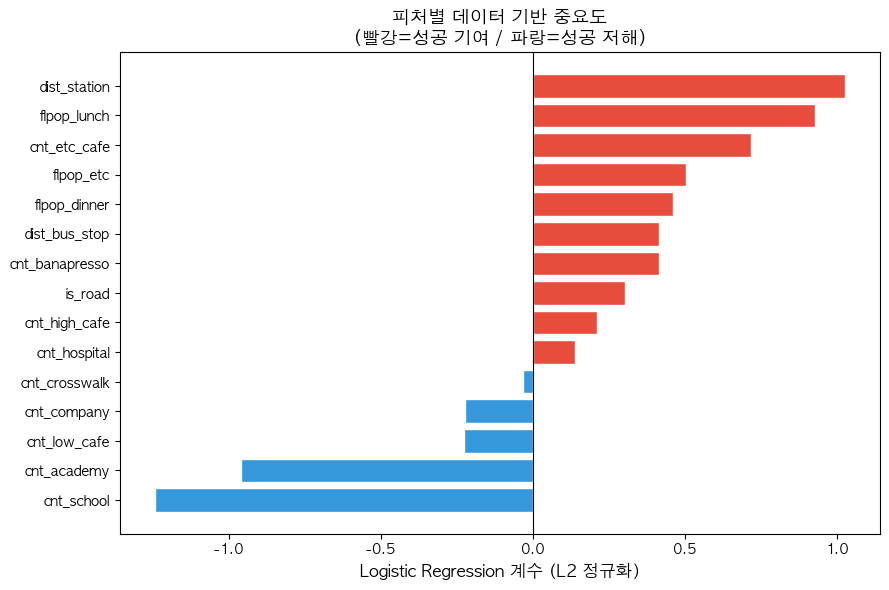


[도메인 가중치 vs 데이터 기반 계수 비교]


,도메인_가중치,LR_계수
dist_station,0.10,1.027863
flpop_lunch,0.15,0.928928
cnt_etc_cafe,0.03,0.717420
flpop_etc,0.10,0.503079
flpop_dinner,0.15,0.461386
dist_bus_stop,0.08,0.413661
cnt_banapresso,0.02,0.413094
is_road,0.05,0.302765
cnt_high_cafe,0.03,0.210531
cnt_hospital,0.05,0.136864


In [35]:
coef = pd.Series(lr_model.coef_[0], index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in coef.values]
ax.barh(coef.index, coef.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression 계수 (L2 정규화)', fontsize=12)
ax.set_title('피처별 데이터 기반 중요도\n(빨강=성공 기여 / 파랑=성공 저해)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_coef.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n[도메인 가중치 vs 데이터 기반 계수 비교]')
compare = pd.DataFrame({
    '도메인_가중치': pd.Series(weights),
    'LR_계수':      coef
}).sort_values('LR_계수', ascending=False)
compare

### 7.5 도메인 가중치 vs LR 계수 비교 해석

도메인 기반 가중치와 Logistic Regression이 학습한 계수를 비교하여 입지 요인의 중요도를 검증하였다.

분석 결과 역세권 접근성과 점심 시간 유동인구가 성공 매장의 주요 특징으로 나타났으며,

일부 변수(학교·학원)는 도메인 가설과 다른 패턴을 보였다. 

아마 학원 많은 곳은 경쟁 저가 카페가 많기 때문인듯

## 8. 매물 성공 확률 예측 & 추천


도메인 점수(기본 입지 기준 미달 매물 제거) -> Logistic Regression (검증한 성공 가능성 순서로 최종 추천)

### 8.1 도메인 점수 계산

공동 스케일링된 listing feature에 가중치 적용.

bana_df도 동일 스케일로 재계산해 기준선(성공 매장 평균)으로 활용.

In [36]:
# 스케일링된 listing 피처로 도메인 점수 계산
listing_scaled_df = pd.DataFrame(X_listing, columns=feature_cols,
                                  index=listing_df.index)

# 입지 점수 계산
listing_df['location_score'] = listing_scaled_df.apply(
    lambda row: sum(row[col] * weights[col] for col in weights), axis=1
)

# bana_df도 동일 스케일로 재계산
bana_scaled_df = pd.DataFrame(X_bana, columns=feature_cols, index=bana_df.index)
bana_df['location_score_v2'] = bana_scaled_df.apply(
    lambda row: sum(row[col] * weights[col] for col in weights), axis=1
)

print(' 매물 입지 점수 분포 ')
print(listing_df['location_score'].describe().round(3))
bana_avg = bana_df[bana_df['success']==1]['location_score_v2'].mean()
print(f'\n성공 매장 평균: {bana_avg:.3f}')

 매물 입지 점수 분포 
count    1319.000
mean        0.321
std         0.062
min         0.143
25%         0.268
50%         0.320
75%         0.366
max         0.485
Name: location_score, dtype: float64

성공 매장 평균: 0.400


### 8.2 성공 확률 예측

`predict_proba()[:, 1]` = 해당 매물에 바나프레소가 입점했을 때 3년 이상 생존할 확률


In [37]:
listing_df['success_prob'] = lr_model.predict_proba(X_listing)[:, 1]

print('매물 성공 확률 분포')
print(listing_df['success_prob'].describe().round(3))

매물 성공 확률 분포
count    1319.000
mean        0.479
std         0.110
min         0.194
25%         0.419
50%         0.486
75%         0.563
max         0.743
Name: success_prob, dtype: float64


### 8.3 TOP 20 추천

- location_score로 상위 50% 
- success_prob로 내림차순 정렬 → TOP 20

In [38]:
# 도메인 점수 상위 50% 필터
threshold = listing_df['location_score'].median()
candidates = listing_df[listing_df['location_score'] >= threshold].copy()
print(f'도메인 점수 필터 후 후보: {len(candidates):,}건 (전체 {len(listing_df):,}건 중)')

# 성공 확률 순위
show_cols = ['listing_id','addr','floor',
             'deposit_만원','monthly_rent_만원','size_평',
             'flpop_lunch','flpop_dinner',
             'dist_station','cnt_crosswalk','is_road',
             'location_score','success_prob']
show_cols = [c for c in show_cols if c in candidates.columns]

top20 = candidates.nlargest(20, 'success_prob')[show_cols].copy().reset_index(drop=True)
top20.index += 1

fmt = {'deposit_만원':'{:,.0f}만'.format, 'monthly_rent_만원':'{:,.0f}만'.format,
       'flpop_lunch':'{:,.0f}'.format,   'flpop_dinner':'{:,.0f}'.format,
       'dist_station':'{:.0f}m'.format,
       'location_score':'{:.4f}'.format, 'success_prob':'{:.4f}'.format}
for col, fn in fmt.items():
    if col in top20.columns:
        top20[col] = top20[col].map(fn)

print('\n바나프레소 입지 추천 TOP 20')
top20

도메인 점수 필터 후 후보: 665건 (전체 1,319건 중)

바나프레소 입지 추천 TOP 20


,listing_id,addr,floor,deposit_만원,monthly_rent_만원,size_평,flpop_lunch,flpop_dinner,dist_station,cnt_crosswalk,is_road,location_score,success_prob
1,913477,서울특별시 강남구 역삼동,4층,"3,000만",180만,23.0,"985,132","882,135",333m,9,1,0.4854,0.7428
2,419277,서울특별시 강남구 논현동,1층,"3,000만",230만,16.0,"388,874","478,718",58m,16,1,0.4511,0.7060
3,918579,서울특별시 강남구 논현동,3층,"15,339만","1,053만",95.7,"388,874","478,718",80m,10,1,0.4396,0.7003
4,557966,서울특별시 강남구 논현동,지하1층,"10,000만","1,000만",61.0,"388,874","478,718",189m,13,1,0.4282,0.6943
5,553540,서울특별시 강남구 논현동,5층,"8,000만",550만,39.0,"388,874","478,718",189m,13,1,0.4282,0.6943
6,553538,서울특별시 강남구 논현동,4층,"10,000만",600만,40.0,"388,874","478,718",189m,13,1,0.4282,0.6943
7,878448,서울특별시 강남구 논현동,1층,"4,000만",210만,6.0,"388,874","478,718",187m,10,1,0.4136,0.6907
8,921771,서울특별시 강남구 논현동,1층,"1,100만",110만,17.8,"388,874","478,718",211m,13,1,0.4259,0.6902
9,919648,서울특별시 강남구 논현동,지하1층,"3,000만",250만,48.0,"388,874","478,718",93m,18,1,0.4421,0.6838
10,926429,서울특별시 서초구 잠원동,3층,"1,201만",120만,15.6,"388,874","478,718",94m,15,1,0.4203,0.6771


## 9. 지도 시각화


In [39]:
m = folium.Map(location=[37.545, 127.0], zoom_start=11, tiles='cartoDBpositron')

layer_success = folium.FeatureGroup(name='바나프레소 성공 매장', show=True)
layer_fail    = folium.FeatureGroup(name='바나프레소 신규/실패',         show=True)
layer_listing = folium.FeatureGroup(name='추천 매물 TOP 50',            show=True)

for _, row in bana_df.iterrows():
    is_ok = row['success'] == 1
    score = row.get('location_score_v2', row.get('location_score', 0))
    popup = (
        f"<b>{row['nm']}</b><br>"
        f"개점일: {str(row['apv_date'])[:10]}<br>"
        f"입지점수: {score:.3f}<br>"
        f"{'성공' if is_ok else '신규/실패'}"
    )
    folium.Marker(
        [row['lat'], row['lng']],
        icon=folium.Icon(color="pink" if is_ok else "lightgray",
                         icon='star' if is_ok else 'times', prefix='fa'),
        popup=folium.Popup(popup, max_width=230)
    ).add_to(layer_success if is_ok else layer_fail)

# 추천 매물: 후보 중 success_prob 상위 50개
top50 = candidates.nlargest(50, 'success_prob').reset_index(drop=True)
top50['rank'] = top50.index + 1

def rank_color(r): return 'red' if r<=10 else ('orange' if r<=30 else 'green')

cluster = MarkerCluster().add_to(layer_listing)
for _, row in top50.iterrows():
    rk   = int(row['rank'])
    dep  = row.get('deposit_만원',      row.get('deposit', 0) / 10_000)
    rent = row.get('monthly_rent_만원', row.get('monthly_rent', 0) / 10_000)
    size = row.get('size_평',           row.get('size_m2', 0) / 3.3058)
    popup = (
        f"<b>{rk}위 추천 매물</b><br>"
        f"위치 : {row.get('addr','')}<br>"
        f"{row.get('floor','')}  {size:.1f}평<br><hr>"
        f"보증금: {dep:,.0f}만원 / 월세: {rent:,.0f}만원<br><hr>"
        f"🚶 점심유동인구: {row.get('flpop_lunch',0):,.0f}<br>"
        f"🚶 저녁유동인구: {row.get('flpop_dinner',0):,.0f}<br>"
        f"🚇 지하철접근성: {row.get('dist_station',0):.0f}m<br>"
        f"🛣 대로변접근성: {'근접' if row.get('is_road',0)==1 else '원격'}<br><hr>"
        f"입지점수: <b>{row.get('location_score',0):.4f}</b><br>"
        f"성공확률: <b>{row.get('success_prob',0):.4f}</b>"
    )
    folium.Marker(
        [row['lat'], row['lng']],
        icon=folium.Icon(color=rank_color(rk), icon='home', prefix='fa'),
        popup=folium.Popup(popup, max_width=270)
    ).add_to(cluster)

layer_success.add_to(m)
layer_fail.add_to(m)
layer_listing.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

legend = """
<div style='position:fixed;bottom:30px;left:30px;z-index:1000;background:white;
            padding:12px 16px;border-radius:8px;border:2px solid #aaa;
            font-size:13px;line-height:1.9;box-shadow:2px 2px 6px rgba(0,0,0,.2)'>
  <b>범례</b><br>
  <span style='color:steelblue'>★</span> 바나프레소 성공<br>
  <span style='color:crimson'>✕</span> 바나프레소 신규/실패<br>
  <span style='color:crimson'>⌂</span> 추천 TOP 1~10<br>
  <span style='color:darkorange'>⌂</span> 추천 TOP 11~30<br>
  <span style='color:green'>⌂</span> 추천 TOP 31~50
</div>"""
m.get_root().html.add_child(folium.Element(legend))

m.save('banaresso_map.html')
print('저장 완료 → banaresso_map.html')
m

저장 완료 → banaresso_map.html


In [40]:
save_cols = ['listing_id','addr','lat','lng','floor',
             'deposit_만원','monthly_rent_만원','size_평',
             'flpop_lunch','flpop_dinner','flpop_etc',
             'dist_station','dist_bus_stop','cnt_crosswalk','is_road',
             'cnt_academy','cnt_hospital','cnt_school','cnt_company',
             'cnt_banapresso','cnt_high_cafe','cnt_low_cafe','cnt_etc_cafe',
             
             'location_score','success_prob']
save_cols = [c for c in save_cols if c in listing_df.columns]

out = (listing_df[save_cols]
       .sort_values('success_prob', ascending=False)
       .reset_index(drop=True))
out.index += 1
out.to_csv('banaresso_listing_scored.csv', index_label='rank', encoding='utf-8-sig')

print(f'저장 완료: banaresso_listing_scored.csv ({len(out):,}건)')
out[['addr','floor','deposit_만원','monthly_rent_만원',
     'location_score','success_prob']].head(10)

저장 완료: banaresso_listing_scored.csv (1,319건)


,addr,floor,deposit_만원,monthly_rent_만원,location_score,success_prob
1,서울특별시 강남구 역삼동,4층,3000.0,180.0,0.485403,0.742783
2,서울특별시 강남구 논현동,1층,3000.0,230.0,0.451112,0.705953
3,서울특별시 강남구 논현동,3층,15339.0,1053.0,0.439575,0.700345
4,서울특별시 강남구 논현동,4층,10000.0,600.0,0.428244,0.694309
5,서울특별시 강남구 논현동,5층,8000.0,550.0,0.428244,0.694309
6,서울특별시 강남구 논현동,지하1층,10000.0,1000.0,0.428244,0.694309
7,서울특별시 강남구 논현동,1층,4000.0,210.0,0.413576,0.690670
8,서울특별시 강남구 논현동,1층,1100.0,110.0,0.425905,0.690155
9,서울특별시 강남구 논현동,지하1층,3000.0,250.0,0.442080,0.683774
10,서울특별시 서초구 잠원동,3층,1201.0,120.0,0.420340,0.677116


## 10. 회고

- 학습 데이터 규모가 매우 제한적(59개)이었기 때문에 모델이 성공 패턴을 안정적으로 일반화하기에는 한계가 있었다. 향후에는 바나프레소뿐 아니라 유사 중가 커피 프랜차이즈 데이터를 포함하여 학습 데이터를 수백~수천 건 규모로 확장한다면 모델의 일반화 성능을 개선할 수 있을 것으로 보인다.

- 제한된 데이터 환경을 고려하여 정확한 예측 모델 구축보다는 상권·입지 특성을 정량화하고 매물 추천 구조를 설계하는 데 분석의 초점을 두었다. 이를 통해 유동인구, 접근성, 주변시설, 경쟁 카페 등의 요소를 기반으로 입지 점수를 계산하고, 머신러닝 모델을 활용해 성공 가능성이 높은 매물을 선별하는 추천 구조를 구현하였다.

